In [1]:
import numpy as np
np.random.seed(42)
m=100
x= 2*np.random.rand(m,1)
y= 4 + 3*x + np.random.randn(m,1)

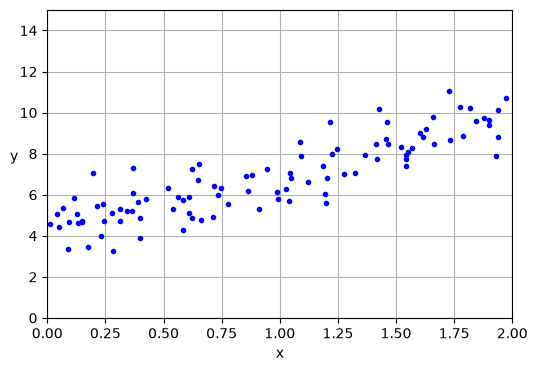

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(x,y,"b.")
plt.axis([0,2,0,15])
plt.xlabel("x")
plt.ylabel("y",rotation=0)
plt.grid()
plt.show()

In [ ]:
from sklearn.preprocessing import add_dummy_feature
x_b=add_dummy_feature(x)
theta= np.linalg.inv(x_b.T @ x_b) @ x_b.T @ y 


In [4]:
theta

array([[4.21509616],
       [2.77011339]])

In [5]:
x_new = np.array([[0],[2]])
x_new_b=add_dummy_feature(x_new)
y_predict=x_new_b @ theta

In [6]:
y_predict

array([[4.21509616],
       [9.75532293]])

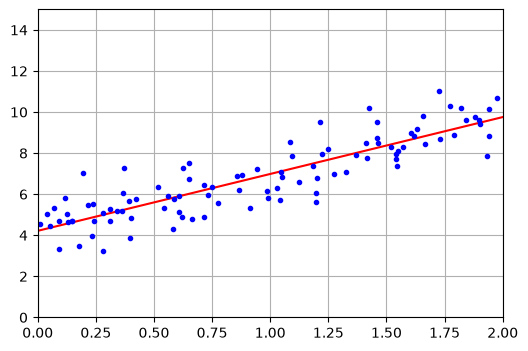

In [7]:
plt.figure(figsize=(6,4))
plt.plot(x_new,y_predict,"r-",label="Prediction")
plt.plot(x,y,'b.')
plt.axis([0,2,0,15])
plt.grid()
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression

lin=LinearRegression()
lin.fit(x,y)
lin.predict(x_new)

array([[4.21509616],
       [9.75532293]])

In [9]:
lin.intercept_

array([4.21509616])

In [10]:
lin.coef_

array([[2.77011339]])

In [11]:
#batch Gradient Descent

eta =0.01
epochs=1000
np.random.seed(42)
theta=np.random.randn(2,1)

for epoch in range(epochs):
    gradients=2/m * x_b.T @(x_b @ theta -y)
    theta = theta - eta * gradients
    

In [12]:
theta


array([[4.1935218 ],
       [2.78916237]])

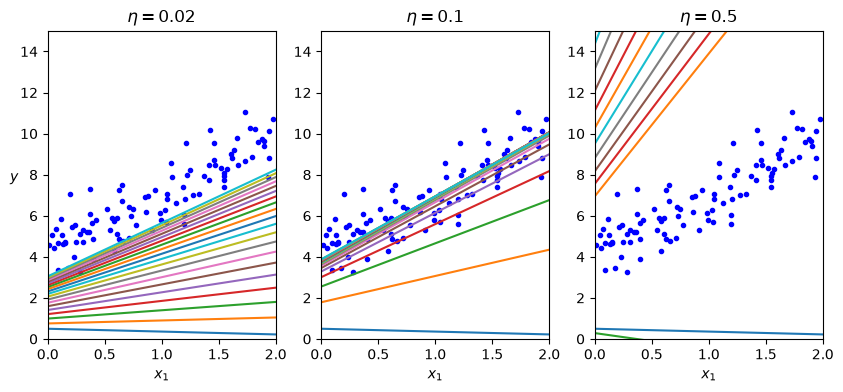

In [23]:
#ploting the graph

def plot_graph(theta,eta):
    m=len(x_b)
    epochs=1000
    n_shown=20
    theta_path=[]
    plt.plot(x,y,"b.")
    plt.grid()
    for epoch in range(epochs):
        if epoch < n_shown:
            y_predict=x_new_b @ theta
            plt.plot(x_new,y_predict, linestyle="solid")
        gradients=2/m *x_b.T @ (x_b @ theta -y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta=np.random.randn(2,1)

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_graph(theta,eta =0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_graph(theta,eta=0.1)

plt.subplot(133)

plot_graph(theta,eta=0.5)
plt.show()